In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/README.dataset.txt
/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/README.roboflow.txt
/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/data.yaml
/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/valid/labels/Huddle-at-ndv-350x450_jpg.rf.999513243e1640c111beb256d20c1c23.txt
/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/valid/labels/6frame107_jpg.rf.44131d134d9d216cb9c525f2d61bd0b3.txt
/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/valid/labels/photo_3_2023-01-14_00-02-11_jpg.rf.a52fc5e3e4877faa9a50d9c13cdc8000.txt
/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/valid/labels/photo_5_2023-01-14_00-03-32_jpg.rf.be7ad071b7dc9e6121ce4bedf2e7814b.txt
/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/valid/labels/video-

In [13]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import shutil

for filename in os.listdir('/kaggle/working'):
    file_path = os.path.join('/kaggle/working', filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
    except Exception as e:
        print(f'Failed to delete {file_path}. Reason: {e}')

In [15]:
from pathlib import Path

SRC = Path("/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1")   # <-- apne dataset ka path (train/ valid/ test/ isi ke andar hon)
OUT = Path("/kaggle/working/data")
NC = 2
NAMES = ["Sick", "Healthy"]

print(list(SRC.iterdir()))

[PosixPath('/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/README.dataset.txt'), PosixPath('/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/README.roboflow.txt'), PosixPath('/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/data.yaml'), PosixPath('/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/valid'), PosixPath('/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/test'), PosixPath('/kaggle/input/datasets/aqiii2742/broiler-chicken-healthy-and-sick-dataset-v1/train')]


In [19]:
import re, random, shutil

def clean_line(line):
    """YOLO det ya seg line -> (cls, cx, cy, w, h) ya None (agar kharab ho)"""
    try:
        v = [float(x) for x in line.split()]
    except ValueError:
        return None
    if len(v) < 5: return None
    c, p = v[0], v[1:]
    if c != int(c) or not 0 <= c < NC: return None          # galat class
    if max(abs(x) for x in p) > 1.05: return None            # normalized nahi
    if len(p) == 4:                                          # detection
        cx, cy, w, h = p
        xs, ys = [cx - w/2, cx + w/2], [cy - h/2, cy + h/2]
    elif len(p) >= 6:                                        # segmentation polygon
        if len(p) % 2: p = p[:-1]                            # odd value fix
        xs, ys = p[0::2], p[1::2]
    else:
        return None
    x1, x2 = max(0, min(xs)), min(1, max(xs))                # image ke andar clip
    y1, y2 = max(0, min(ys)), min(1, max(ys))
    if x2 - x1 < 0.003 or y2 - y1 < 0.003: return None       # bohat chhota / degenerate
    return int(c), round((x1+x2)/2, 6), round((y1+y2)/2, 6), round(x2-x1, 6), round(y2-y1, 6)

def group(stem):   # Roboflow augmentation: name_jpg.rf.<hash>  -> name
    return re.sub(r"[_.](jpg|jpeg|png)\.rf\.\w+$", "", stem, flags=re.I)

data, total, kept = {}, 0, 0
for name, folder in [("train", "train"), ("val", "valid"), ("test", "test")]:
    items = []
    for img in sorted((SRC/folder/"images").glob("*.*")):
        lbl = SRC/folder/"labels"/(img.stem + ".txt")
        if not lbl.exists(): continue
        lines = [l for l in lbl.read_text().splitlines() if l.strip()]
        rows = list(dict.fromkeys(r for r in map(clean_line, lines) if r))   # duplicate hatao
        total += len(lines); kept += len(rows)
        items.append((img, rows))
    data[name] = items
print(f"label rows: {total} -> kept {kept}, removed/duplicate {total-kept}")

# leakage: jin train images ka source val/test mein hai unhein hatao
held = {group(i.stem) for n in ("val", "test") for i, _ in data[n]}
data["train"] = [x for x in data["train"] if group(x[0].stem) not in held]

# train ke 10% source-groups val mein (val sirf 53 images hai, kam hai)
groups = sorted({group(i.stem) for i, _ in data["train"]})
random.seed(42); random.shuffle(groups)
vg = set(groups[: len(groups)//10])
data["val"] += [x for x in data["train"] if group(x[0].stem) in vg]
data["train"] = [x for x in data["train"] if group(x[0].stem) not in vg]

# files likho
shutil.rmtree(OUT, ignore_errors=True)
for split, items in data.items():
    (OUT/split/"images").mkdir(parents=True); (OUT/split/"labels").mkdir(parents=True)
    for img, rows in items:
        shutil.copy(img, OUT/split/"images"/img.name)
        (OUT/split/"labels"/(img.stem + ".txt")).write_text("".join(f"{c} {a} {b} {w} {h}\n" for c, a, b, w, h in rows))
    n0 = sum(r[0] == 0 for _, rows in items for r in rows); n1 = sum(r[0] == 1 for _, rows in items for r in rows)
    print(f"{split:5s} images={len(items):5d}  diseased_boxes={n0}  healthy_boxes={n1}")

(OUT/"data.yaml").write_text(f"path: {OUT}\ntrain: train/images\nval: val/images\ntest: test/images\nnc: {NC}\nnames: {NAMES}\n")

label rows: 6410 -> kept 6409, removed/duplicate 1
train images= 1652  diseased_boxes=2020  healthy_boxes=3069
val   images=  233  diseased_boxes=261  healthy_boxes=421
test  images=   26  diseased_boxes=15  healthy_boxes=47


134

In [20]:
from ultralytics import YOLO

model = YOLO("yolov8s.yaml")      # .yaml = sirf architecture, random weights

model.train(
    data=str(OUT/"data.yaml"),
    pretrained=False,
    epochs=300, patience=50,
    imgsz=640, batch=16, workers=2, device=0,
    optimizer="SGD", lr0=0.01, cos_lr=True, warmup_epochs=5, close_mosaic=30,
    mosaic=1.0, mixup=0.1, fliplr=0.5, flipud=0.0, scale=0.5, hsv_v=0.4,
    max_det=1000, cache="ram", seed=0,
    project="/kaggle/working/runs", name="chicken", exist_ok=True,
)

Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=None, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=1000, mixup=0.1, mode=train, model=yolov8s.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=chicken, nbs=64, nms=None, opset=None, optimize=False, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1e1625c0b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [24]:
best = YOLO("/kaggle/working/runs/chicken/weights/best.pt")

for split in ["val", "test"]:
    m = best.val(data=str(OUT/"data.yaml"), split=split, conf=0.001, max_det=1000)
    print(split, "| P: %.3f  R: %.3f  mAP50: %.3f  mAP50-95: %.3f" % (m.box.mp, m.box.mr, m.box.map50, m.box.map))
    for i, c in enumerate(m.box.ap_class_index):
        print("   ", NAMES[int(c)], "P: %.3f  R: %.3f  AP50: %.3f" % (m.box.p[i], m.box.r[i], m.box.ap50[i]))

Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1215.1±476.5 MB/s, size: 46.1 KB)
val: Scanning /kaggle/working/data/val/labels.cache... 233 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233 97.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.2it/s 4.6s0.2s
                   all        233        682      0.727       0.64      0.699      0.388
      diseased-chicken        153        261      0.765      0.835      0.851      0.524
       healthy-chicken         86        421      0.688      0.444      0.548      0.252
Speed: 2.1ms preprocess, 10.7ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
val | P: 0.727  R: 0.640  mAP50: 0.699  mAP50-95: 0.388
    diseased-chicken P: 0.76

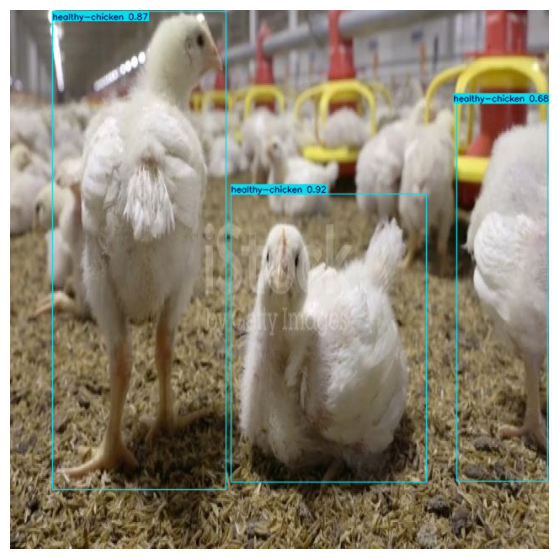

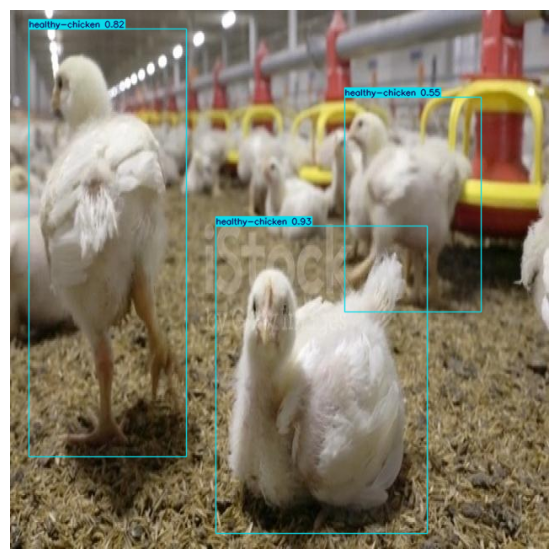

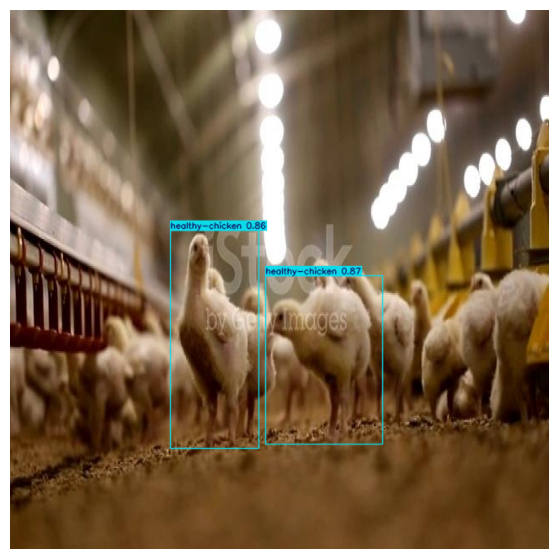

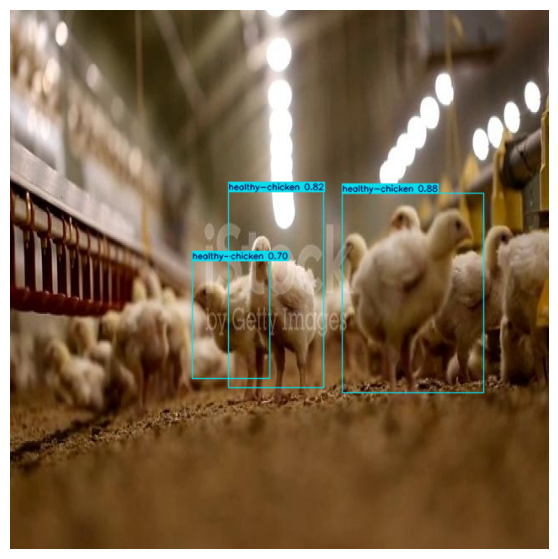

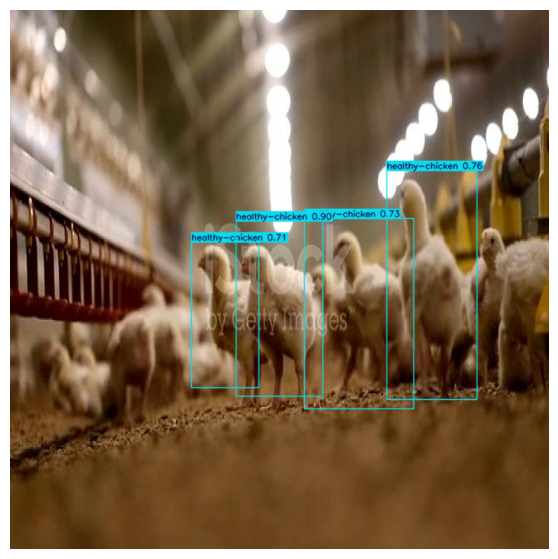

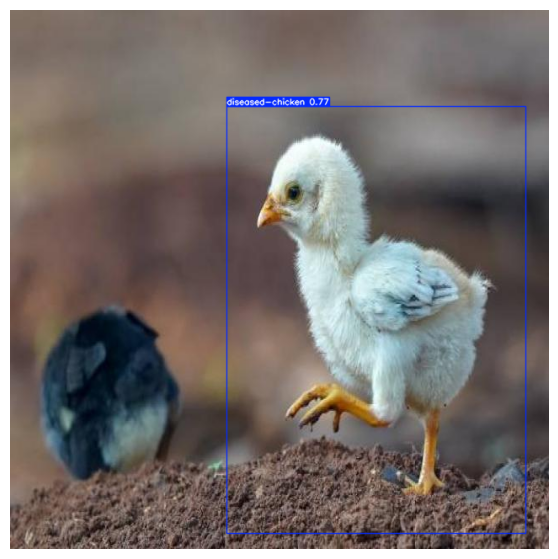

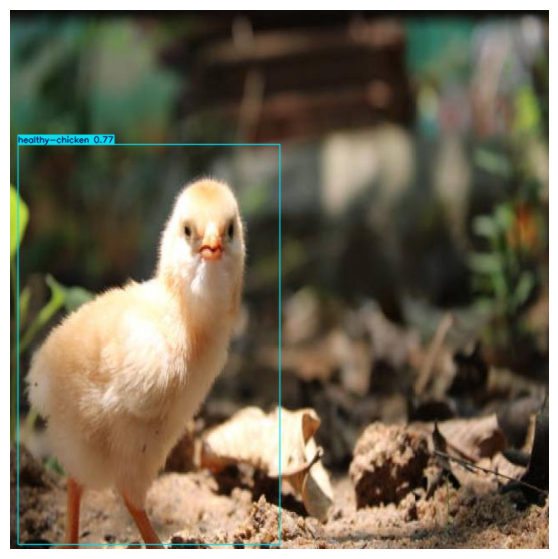

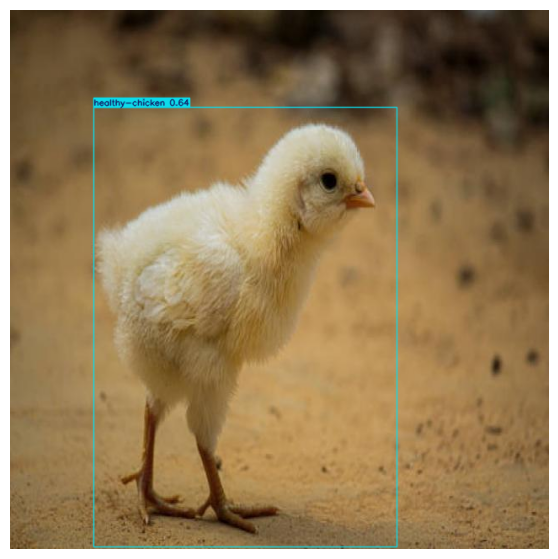

In [25]:
import matplotlib.pyplot as plt

results = best.predict(source=str(OUT/"test/images"), conf=0.3, max_det=1000, verbose=False)
for r in results[:8]:
    plt.figure(figsize=(7, 7))
    plt.imshow(r.plot(line_width=1)[..., ::-1]); plt.axis("off")
plt.show()

In [26]:
m = best.val(data=str(OUT/"data.yaml"), split="val", conf=0.25, iou=0.6, max_det=1000, plots=True)
print(m.confusion_matrix.matrix.astype(int))

Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8s summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1395.2±530.5 MB/s, size: 54.1 KB)
val: Scanning /kaggle/working/data/val/labels.cache... 233 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 233/233 69.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.4it/s 4.5s0.2s
                   all        233        682      0.725      0.651      0.643      0.364
      diseased-chicken        153        261      0.761      0.843      0.824      0.505
       healthy-chicken         86        421      0.688      0.458      0.462      0.222
Speed: 1.8ms preprocess, 10.7ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-3
[[232  23 106]
 [ 18 241 171]
 [ 11 157   0]]


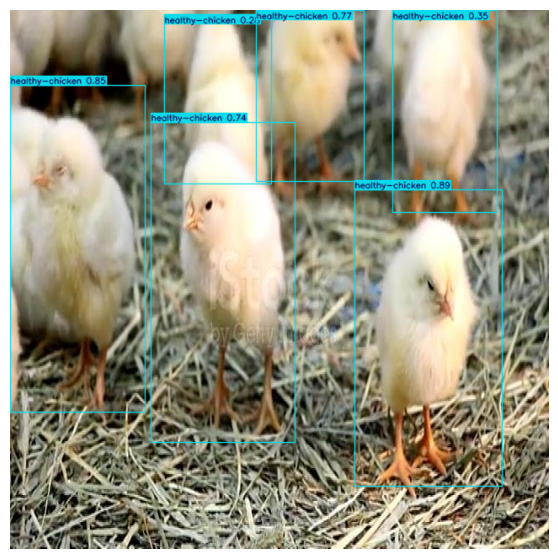

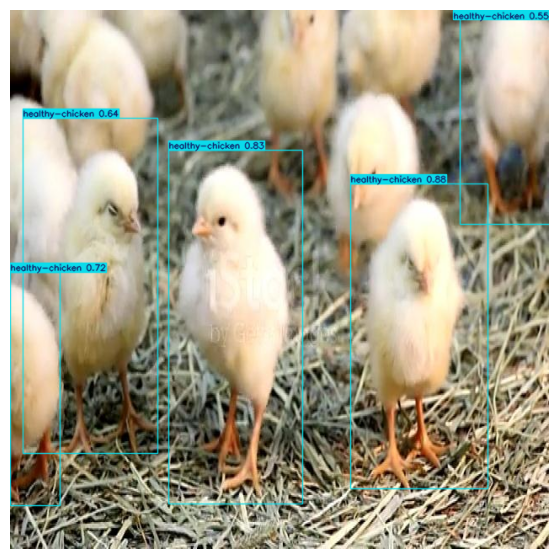

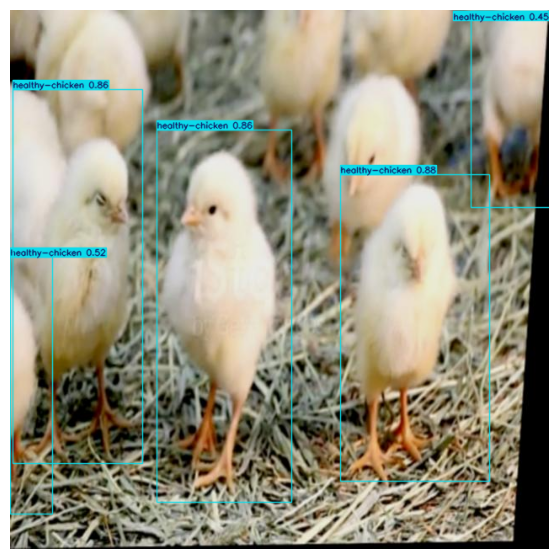

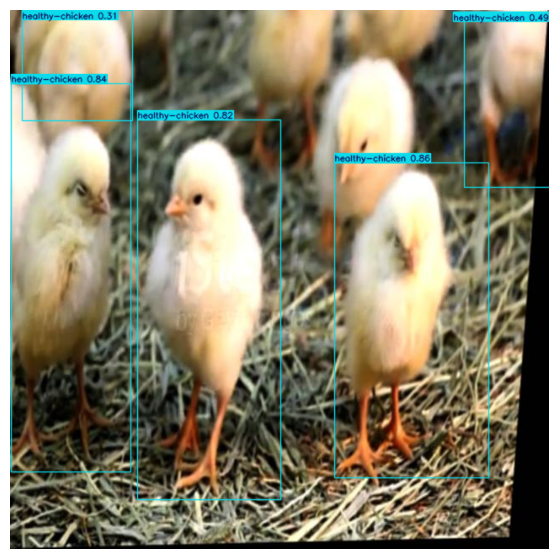

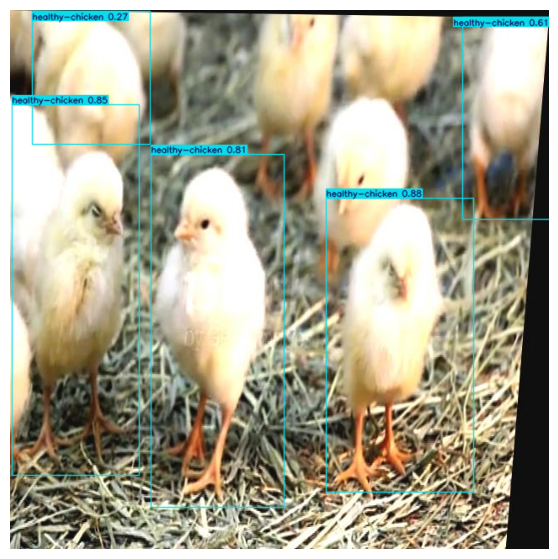

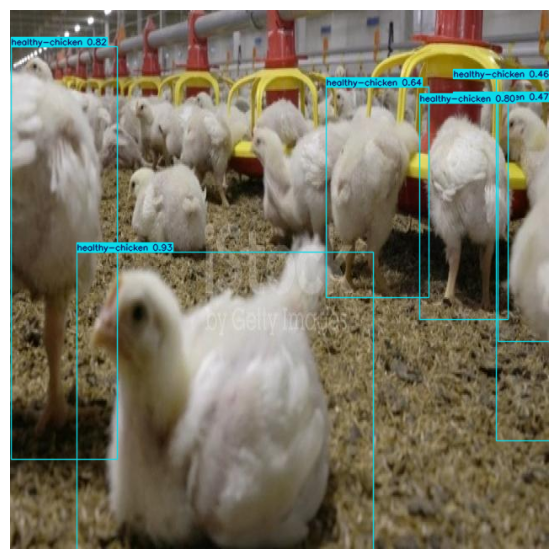

In [27]:
import matplotlib.pyplot as plt
r = best.predict(source=str(OUT/"val/images"), conf=0.25, max_det=1000, verbose=False)
# healthy wali images pehle dekhne ke liye:
imgs = [x for x in r if (x.boxes.cls == 1).any() or len(x.boxes) == 0][:6]
for x in imgs:
    plt.figure(figsize=(7, 7)); plt.imshow(x.plot(line_width=1)[..., ::-1]); plt.axis("off")
plt.show()

In [28]:
import os
from IPython.display import FileLink

# 1. Compress the directory into a zip file
!zip -r my_outputs.zip /kaggle/working/

# 2. Create a clickable download link for the zip file
FileLink(r'my_outputs.zip')

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/weights/ (stored 0%)
  adding: kaggle/working/weights/yolo26n.pt (deflated 11%)
  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/chicken/ (stored 0%)
  adding: kaggle/working/runs/chicken/BoxF1_curve.png (deflated 12%)
  adding: kaggle/working/runs/chicken/BoxP_curve.png (deflated 12%)
  adding: kaggle/working/runs/chicken/BoxR_curve.png (deflated 12%)
  adding: kaggle/working/runs/chicken/val_batch0_pred.jpg (deflated 7%)
  adding: kaggle/working/runs/chicken/val_batch0_labels.jpg (deflated 7%)
  adding: kaggle/working/runs/chicken/confusion_matrix.png (deflated 29%)
  adding: kaggle/working/runs/chicken/train_batch2.jpg (deflated 3%)
  adding: kaggle/working/runs/chicken/val_batch2_pred.jpg (deflated 5%)
  adding: kaggle/working/runs/chicken/weights/ (stored 0%)
  adding: kaggle/working/runs/chicken/weights/last.pt (deflated 9%)
  adding: kaggle/working/runs/chicken/weights/best.pt (deflated 9%)
  

/kaggle/working/my_outputs.zip